In [1]:
import numpy as np
import torch
import normflows as nf

from pid.models import CartesianProductFlow
from pid.optimizers import exact_gauss_tilde_pid, exact_gauss_thin_pid, flow_pid
import pid.models.lmi as lmi
from pid.utils import generate_randomBC

from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
dm = 2  # Number of dimensions of M
dx = 50
dy = 20

# set manual seed
torch.manual_seed(0)
np.random.seed(0)

hx, hy = generate_randomBC(dm, dx, dy)

sigm = np.eye(dm)
sigx_m = np.eye(dx)
sigy_m = np.eye(dy)
sigw = np.zeros((dx, dy))

# Covariance matrix construction for both unique or redundant
cov = np.block([[sigm, sigm @ hx.T, sigm @ hy.T],
                [hx @ sigm, hx @ sigm @ hx.T + sigx_m, hx @ sigm @ hy.T + sigw],
                [hy @ sigm, hy @ sigm @ hx.T + sigw.T, hy @ sigm @ hy.T + sigy_m]])

print(cov.shape)

ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Tilde-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

ret = exact_gauss_thin_pid(cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Thin-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

(72, 72)
Tilde-PID: R: 4.45834790044597, U1: 1.2394684294875198, U2: 0.0, S: 0.4974090065072021
Thin-PID: R: 4.458347898995697, U1: 1.2394684309377926, U2: 1.4502727907483859e-09, S: 0.4974090050569293


In [3]:
n = 100000   # number of samples

mean = np.zeros(dm+dx+dy)
mxy = np.random.multivariate_normal(mean, cov, size=n)
cov = np.corrcoef(mxy.T)

ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"GPID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

ret = exact_gauss_thin_pid(cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Thin-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

GPID: R: 4.465818017683039, U1: 1.239434762799256, U2: 0.0, S: 0.4967409364819364
Thin-PID: R: 4.465818013807153, U1: 1.2394347666751413, U2: 3.875885390414169e-09, S: 0.496740932606051


In [4]:
m_data, x_data, y_data = np.hsplit(mxy, [dm, dm+dx])  # split m, x, y
print(m_data.shape, x_data.shape, y_data.shape)

x_data = x_data**3
y_data = np.cbrt(y_data)

def standardize_data(data):
    data = torch.from_numpy(np.nan_to_num((data - data.mean(axis=0)) / data.std(axis=0))).float()
    data = torch.clip(data, min=-10, max=10)
    return data

m_data_standardized = standardize_data(m_data)
x_data_standardized = standardize_data(x_data)
y_data_standardized = standardize_data(y_data)

dataset = TensorDataset(x_data_standardized, y_data_standardized, m_data_standardized)
train_loader = DataLoader(dataset, batch_size=512, shuffle=True)

enable_cuda=True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
print(f"Using device: {device}")

(100000, 2) (100000, 50) (100000, 20)
Using device: cuda


In [5]:
def train_lmi(model, dataloader, lr=0.0001, epochs=300, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, eps=1e-07)

    ############# training loop #############
    losses = []
    for epoch in tqdm(range(epochs)):
        epoch_losses = []
        for batch_n, (x_batch, y_batch, m_batch) in enumerate(train_loader):
            x_batch, y_batch, m_batch = x_batch.to(device), y_batch.to(device), m_batch.to(device)

            model.train()
            optimizer.zero_grad()

            loss = model.learning_loss(x_batch, y_batch, m_batch)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        avg_loss = sum(epoch_losses) / len(epoch_losses)
        losses.append(avg_loss)

    if verbose:
        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.show()

    return model

100%|██████████| 2000/2000 [40:09<00:00,  1.20s/it]


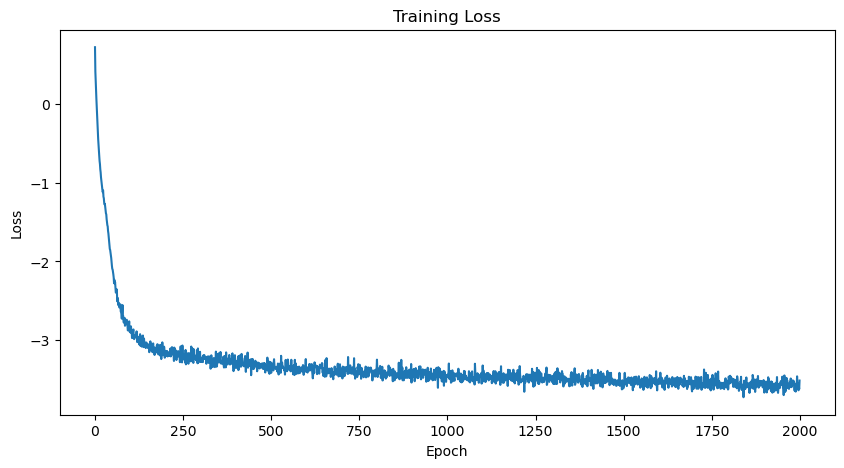

In [6]:
latent_dim = 8

encoder = lmi.AEMINE(dx, dy, dm, latent_dim, alpha=1.0, lam=1.0).to(device)
lmi_encoder = train_lmi(encoder, train_loader, lr=2e-4, epochs=2000, verbose=True)

In [7]:
# Use the trained encoder to get the latent representations
x_latent = []
y_latent = []
m_latent = []
for x_batch, y_batch, m_batch in train_loader:
    lmi_encoder.eval()
    x_batch, y_batch, m_batch = x_batch.to(device), y_batch.to(device), m_batch.to(device)

    with torch.no_grad():
        Z_x, Z_y = lmi_encoder.encode(x_batch, y_batch)
    Z_m = m_batch

    x_latent.append(Z_x)
    y_latent.append(Z_y)
    m_latent.append(Z_m)

x_latent = torch.cat(x_latent)
y_latent = torch.cat(y_latent)
m_latent = torch.cat(m_latent)

x_data_standardized = standardize_data(x_latent.cpu().numpy())
y_data_standardized = standardize_data(y_latent.cpu().numpy())
m_data_standardized = standardize_data(m_latent.cpu().numpy())

print(x_data_standardized.shape, y_data_standardized.shape, m_data_standardized.shape)

torch.Size([100000, 8]) torch.Size([100000, 8]) torch.Size([100000, 2])


In [8]:
new_mxy = np.hstack((m_data_standardized.cpu().numpy(), x_data_standardized.cpu().numpy(), y_data_standardized.cpu().numpy()))
new_cov = np.corrcoef(new_mxy.T)
print(new_cov.shape)

ret = exact_gauss_tilde_pid(new_cov, dm, latent_dim, latent_dim)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Tilde-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

ret = exact_gauss_thin_pid(new_cov, dm, latent_dim, latent_dim)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Thin-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

(18, 18)
Tilde-PID: R: 4.121528193642405, U1: 0.9162442290804611, U2: 0.0, S: 0.8115820576532444
Thin-PID: R: 4.121528192681182, U1: 0.9162442300416842, U2: 9.612231011146832e-10, S: 0.8115820566920213


In [9]:
from pid.models import norm_flows
K = 64

# Construct flow model
nfm_x = nf.NormalizingFlow(
    q0=nf.distributions.base.GaussianPCA(latent_dim, dm),
    flows=norm_flows(n_flows=K, latent_size=latent_dim)
).to(device)

nfm_y = nf.NormalizingFlow(
    q0=nf.distributions.base.GaussianPCA(latent_dim, dm),
    flows=norm_flows(n_flows=K, latent_size=latent_dim)
).to(device)

nfm_m = nf.NormalizingFlow(
    q0=nf.distributions.base.DiagGaussian(dm, dm),
    flows=norm_flows(n_flows=K, latent_size=dm)
).to(device)

mxy_dim = dm + latent_dim * 2
nfm_mxy = nf.NormalizingFlow(
    q0=nf.distributions.base.GaussianPCA(mxy_dim, dm),
    flows=norm_flows(n_flows=K, latent_size=mxy_dim)
).to(device)

100%|██████████| 782/782 [01:34<00:00,  8.31it/s]


Train Epoch: 0/30 (0%)	Loss: 84.037823


100%|██████████| 782/782 [01:36<00:00,  8.13it/s]


Train Epoch: 1/30 (3%)	Loss: 19.369343


100%|██████████| 782/782 [01:35<00:00,  8.19it/s]


...

Train Epoch: 27/30 (90%)	Loss: -27.815613


100%|██████████| 782/782 [01:33<00:00,  8.39it/s]


Train Epoch: 28/30 (93%)	Loss: -28.920255


100%|██████████| 782/782 [01:32<00:00,  8.45it/s]

Train Epoch: 29/30 (97%)	Loss: -29.689699
Final Loss: -29.6897


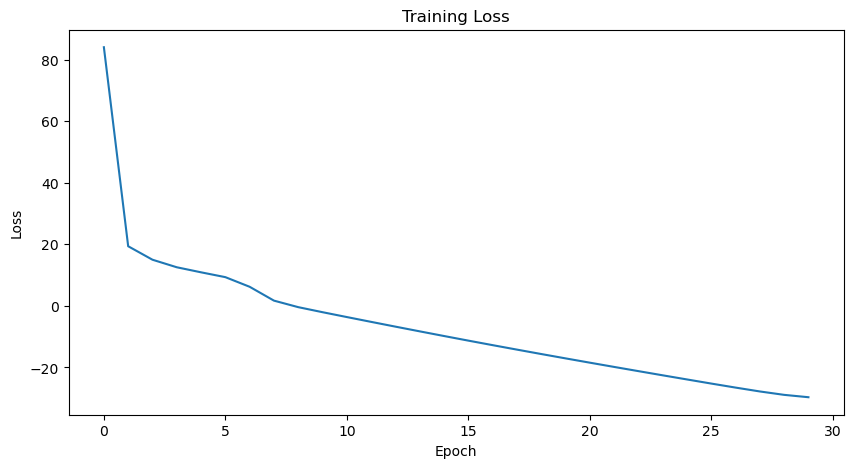

flow pid, normalized I_mxy, R: 0.7573634020431821, U1: 0.11158949694672589, U2: 0.0, S: 0.131047101010092


In [10]:
new_dataset = TensorDataset(x_data_standardized, y_data_standardized, m_data_standardized)
train_loader = DataLoader(new_dataset, batch_size=128, shuffle=True)

model = CartesianProductFlow(
    dm=dm,
    
    dx=latent_dim,
    dy=latent_dim,
    n_flows=32,
).to(device)

pid_flows = flow_pid.fit_flows(model, train_loader, 30, lr=1e-4, device=device, verbose=True)
ret = flow_pid.fit_pid(pid_flows, train_loader, device=device, verbose=True)
norm = ret[7] + ret[5] + ret[6] + ret[8]
print(f"flow pid, normalized I_mxy, R: {ret[7]/norm}, U1: {ret[5]/norm}, U2: {ret[6]/norm}, S: {ret[8]/norm}")

In [11]:
def train_one_step(model, optimizer, x):
    optimizer.zero_grad()
    loss = model.forward_kld(x)

    if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()
            optimizer.step()

    return loss

n_epochs = 30

optimizer_x = torch.optim.Adam(nfm_x.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer_y = torch.optim.Adam(nfm_y.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer_m = torch.optim.Adam(nfm_m.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer_mxy = torch.optim.Adam(nfm_mxy.parameters(), lr=1e-4, weight_decay=1e-4)

for epoch in range(n_epochs):
    progressbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for batch_n, (x, y, m) in progressbar:
        x, y, m = x.to(device), y.to(device), m.to(device)

        loss_x = train_one_step(nfm_x, optimizer_x, x)
        loss_y = train_one_step(nfm_y, optimizer_y, y)
        loss_m = train_one_step(nfm_m, optimizer_m, m)
        # loss_mxy = train_one_step(nfm_mxy, optimizer_mxy, torch.cat([m, x, y], dim=-1))

        loss = loss_x.item() + loss_y.item() + loss_m.item()
        progressbar.update()

    progressbar.close()
    print('Train Epoch: {}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, n_epochs,
                100. * epoch / n_epochs,
                loss))

100%|██████████| 782/782 [03:08<00:00,  4.15it/s]


Train Epoch: 0/30 (0%)]	Loss: 13.010664


100%|██████████| 782/782 [03:07<00:00,  4.16it/s]


Train Epoch: 1/30 (3%)]	Loss: 7.762050


100%|██████████| 782/782 [03:08<00:00,  4.15it/s]


...

Train Epoch: 27/30 (90%)]	Loss: -20.395529


100%|██████████| 782/782 [03:08<00:00,  4.16it/s]


Train Epoch: 28/30 (93%)]	Loss: -20.272700


100%|██████████| 782/782 [03:09<00:00,  4.13it/s]

Train Epoch: 29/30 (97%)]	Loss: -20.406429


In [12]:
from pid.optimizers.flow_pid import covariance_to_correlation

z_mxy = []
for x_batch, y_batch, m_batch in train_loader:
    x_batch, y_batch, m_batch = x_batch.to(device), y_batch.to(device), m_batch.to(device)
    with torch.no_grad():
        z_m = nfm_m.inverse(m_batch)
        z_x = nfm_x.inverse(x_batch)
        z_y = nfm_y.inverse(y_batch)
        z_mxy.append(torch.cat([z_m, z_x, z_y], dim=-1))

        # mxy = nfm_mxy.inverse(torch.cat([m_batch, x_batch, y_batch], dim=-1))
        # z_mxy.append(mxy)

z_mxy = torch.cat(z_mxy, dim=0)
cov = torch.cov(z_mxy.T).cpu().numpy()
trained_cov = covariance_to_correlation(cov)

In [13]:
ret = exact_gauss_thin_pid(trained_cov, dm, latent_dim, latent_dim, verbose=False, ret_t_sigt=False)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Flow-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

Flow-PID: R: 3.3090304583333947, U1: 0.010185367463050987, U2: 0.1657212625231388, S: 0.6811542702583986
